In [6]:
# Setup
import sys
import os

# Check if the code is running in Google Colab
if 'google.colab' in sys.modules:
    print("Detected Google Colab environment.")

    # 1. Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # 2. Define the path to your project folder in Drive
    # IMPORTANT: This is the name of my drive folder. Either make one with the same name, or update the string to your own folder.
    project_path = '/content/drive/My Drive/clinical_trials_embeddings/'

    # 3. Copy utils.py to the local Colab session
    # This makes sure that the utils.py file can be accesed. You can also drag and drop it into the local colab session
    # If your runtime times out, you will need to rerun this or rerun the drag and drop so that the code has access to the utils file
    utils_source = os.path.join(project_path, 'utils.py')

    if os.path.exists(utils_source):
        print(f"Found utils.py at {project_path}")
        print("Copying to local session...")
        !cp "{utils_source}" .
        print("utils.py loaded successfully.")
    else:
        print(f"ERROR: utils.py not found at {utils_source}")
        print("Please check the 'project_path' variable.")

    # 4. Install Dependencies from requirements.txt
    req_path = os.path.join(project_path, 'requirements.txt')
    if os.path.exists(req_path):
        print("Installing dependencies from requirements.txt...")
        !pip install -q -r "{req_path}"
        print("Dependencies installed.")
    else:
        print("requirements.txt not found. Falling back to manual install.")
        !pip install -q sentence-transformers datasets

else:
    print("Detected Local environment.")
    project_path = './'

Detected Google Colab environment.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found utils.py at /content/drive/My Drive/clinical_trials_embeddings/
Copying to local session...
utils.py loaded successfully.
Installing dependencies from requirements.txt...
Dependencies installed.


#  Introduction
## Project: Predicting Clinical Trial Success through Multimodal Data Fusion

This notebook presents the final execution and analysis of our project on predicting clinical trial outcomes. Working with the full **louisbrulenaudet/clinical-trials** dataset (~540,000 trials), we aim to show that combining structured metadata with semantic text embeddings allows for better risk detection compared to unimodal approaches.

A central challenge in this domain is the real-world class imbalance, where successful trials vastly outnumber failures. In this notebook, we implement a  pipeline to address this, moving from naive baselines to a balanced training strategy, and culminating in a custom Multimodal Fusion Neural Network.

The notebook is structured as follows:

1.  **Exploratory Data Analysis (EDA):** An examination of the full dataset's structured features and the extent of class imbalance.
2.  **Feature Engineering (Text Embeddings):** Documentation of the generation of semantic embeddings using `BioClinical-ModernBERT`.
3.  **Data Preparation:** Loading the full dataset and creating Train/Validation/Test splits. *Note: we split the data before balancing to make sure our Test set reflects real-world conditions.*
4.  **Baselines Phase 1 (Unbalanced):** Training Random Forest models on the raw data to establish a baseline and demonstrate the "accuracy paradox" (high accuracy, zero recall).
5.  **Data Balancing Strategy:** Implementing a random downsampling strategy on the training set to recover the predictive signal for failed trials.
6.  **Baselines Phase 2 (Balanced):** Retraining the structured and embedding models to quantify the improvement in Recall (failure detection).
7.  **Multimodal Fusion Model:** Implementing and training a PyTorch-based **Intermediate Fusion Neural Network** on a GPU, combining both data modalities.
8.  **Post-Hoc Analysis & Conclusion:** Optimizing decision thresholds to balance Precision/Recall and presenting a final comparative analysis of all five models.

It is important to note that to run this notebook you will need at least 26 GB of RAM, access to a GPU (Only if you want to retrain the models) and roughly 45-50 GB of disk space.

We ran it using the L4 GPU which is accesable through a payed tier of Colab, which also gives us access to 53 GB of system RAM and 112 GB of disk space.

In [30]:
# Libraries

# Core Data Handling & System
import pandas as pd
import numpy as np
import os
import gc
from datasets import load_dataset

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.utils import resample

# Utility Functions (from our utils.py file)
from utils import (
    fit_and_preprocess_train,
    transform_test_data,
    balance_raw_data,
    ClinicalTrialDataset,
    train_model
)

# Configuration
sns.set_style("whitegrid")
pd.options.display.float_format = '{:.2f}'.format
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
# Load the original dataset (excludes embeddings)

# We load the 'train' split, which contains all the available data,
# and immediately convert it to a pandas DataFrame for EDA.

print("Loading the full dataset from Hugging Face...")
full_df = load_dataset("louisbrulenaudet/clinical-trials", split="train").to_pandas()
print("Dataset loaded.")

# Display initial information about the dataset
print("\nDataset Information:")
full_df.info()

print("\nFirst 5 rows of the raw dataset:")
display(full_df.head())

Loading the full dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/222M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/221M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/221M [00:00<?, ?B/s]

...

data/train-00006-of-00008.parquet:   0%|          | 0.00/222M [00:00<?, ?B/s]

data/train-00007-of-00008.parquet:   0%|          | 0.00/222M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/541897 [00:00<?, ? examples/s]

Dataset loaded.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541897 entries, 0 to 541896
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   nct_id                        541897 non-null  object        
 1   updated_at                    0 non-null       datetime64[us]
 2   brief_title                   541897 non-null  object        
 3   official_title                531911 non-null  object        
 4   acronym                       541897 non-null  object        
 5   study_type                    540977 non-null  object        
 6   overall_status                541897 non-null  object        
 7   study_first_submit_date       541897 non-null  datetime64[ms]
 8   start_date                    0 non-null       datetime64[ms]
 9   primary_completion_date       296575 non-null  datetime64[ms]
 10  completion_date               296424 non-n

,nct_id,updated_at,brief_title,official_title,acronym,study_type,overall_status,study_first_submit_date,start_date,primary_completion_date,...,locations,collaborators,arm_groups,outcomes,overall_officials,study_references,misc_info_module,condition_browse_module,intervention_browse_module,mesh_terms
0,NCT01273766,NaT,Deferasirox in Treating Iron Overload Caused B...,Impact of Intervention With Deferasirox on the...,None,INTERVENTIONAL,COMPLETED,2011-01-07,NaT,NaT,...,"[{'city': 'Winston-Salem', 'country': 'United ...","[{'class': 'NIH', 'name': 'National Cancer Ins...",None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'Wake Forest University Healt...,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D004194', 'term': 'Dise...","{'ancestors': [{'id': 'D007502', 'term': 'Iron...","{'conditions': [{'id': 'D002051', 'term': 'Bur..."
1,NCT00787566,NaT,"Phase 2 Study of Efficacy, Tolerability, and S...","A Randomized, Single Administration, Double-bl...",None,INTERVENTIONAL,COMPLETED,2008-11-05,NaT,NaT,...,[{'city': 'The study is managed by Kendle Inte...,None,None,"{'other': None, 'primary': [{'description': No...",None,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D012817', 'term': 'Sign...","{'ancestors': [{'id': 'D000932', 'term': 'Anti...","{'conditions': [{'id': 'D009325', 'term': 'Nau..."
2,NCT00497666,NaT,Association Between Rosiglitazone Use and Clin...,Retrospective Study Evaluating the Association...,None,OBSERVATIONAL,UNKNOWN,2007-07-06,NaT,NaT,...,"[{'city': 'Zerifin,', 'country': 'Israel', 'fa...",None,None,None,"[{'affiliation': 'Nephrology Division, Assaf H...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D014570', 'term': 'Urol...","{'ancestors': None, 'browseBranches': [{'abbre...","{'conditions': [{'id': 'D007674', 'term': 'Kid..."
3,NCT01978366,NaT,Open Label Extension Study of HT-100 in Patien...,An Open Label Extension Study of HT-100 in Pat...,None,INTERVENTIONAL,TERMINATED,2013-10-31,NaT,2016-04-30,...,"[{'city': 'Sacramento', 'country': 'United Sta...",None,None,"{'other': None, 'primary': [{'description': No...","[{'affiliation': 'AkashiTherapeutics', 'name':...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D020966', 'term': 'Musc...","{'ancestors': [{'id': 'D000970', 'term': 'Anti...","{'conditions': [{'id': 'D009136', 'term': 'Mus..."
4,NCT01971866,NaT,Camera Based System to Monitor Patient Movemen...,Improving Safety and Accuracy of Proton Therap...,DS02,OBSERVATIONAL,TERMINATED,2013-10-17,NaT,NaT,...,"[{'city': 'Jacksonville', 'country': 'United S...",None,None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'University of Florida Proton...,None,"{""versionHolder"": ""2025-06-18""}",None,None,None


# Exploratory Data Analysis (EDA)

This section focuses on developing a grounded understanding of the clinical trials dataset. Our aim is to understand how the data are structured, examine key patterns and distributions, and identify potential issues such as missing values or class imbalance. These insights form the foundation for the preprocessing and modeling steps that follow. All analyses here use the full, unfiltered dataset.

### Structured Feature Analysis

We begin with the structured features that are most likely to influence trial outcomes. These variables were selected for their ability to capture aspects of study design, scale, and participant characteristics:

* **`phases`, `study_type`, `enrollment_count`:** Describe the trial’s stage, format, and size, which together indicate its overall complexity and risk.
* **`lead_sponsor_class`:** Represents the funding source (e.g., industry or academic sponsor), which may correlate with trial design and outcome likelihood.
* **`sex`, `minimum_age`, `maximum_age`:** Define the population under study, helping us gauge demographic scope and potential variability.

Our following analysis examines the extent of missing data and the distributions of these categorical and numerical variables. These findings will guide the development of preprocessing methods and inform early model design decisions.

--- Original Distribution of Trial Statuses ---
overall_status
COMPLETED                    296549
UNKNOWN                       79051
RECRUITING                    66429
TERMINATED                    31493
NOT_YET_RECRUITING            23878
ACTIVE_NOT_RECRUITING         20916
WITHDRAWN                     15333
ENROLLING_BY_INVITATION        4655
SUSPENDED                      1674
WITHHELD                        920
NO_LONGER_AVAILABLE             490
AVAILABLE                       264
APPROVED_FOR_MARKETING          220
TEMPORARILY_NOT_AVAILABLE        25
Name: count, dtype: int64


/tmp/ipython-input-2223243746.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


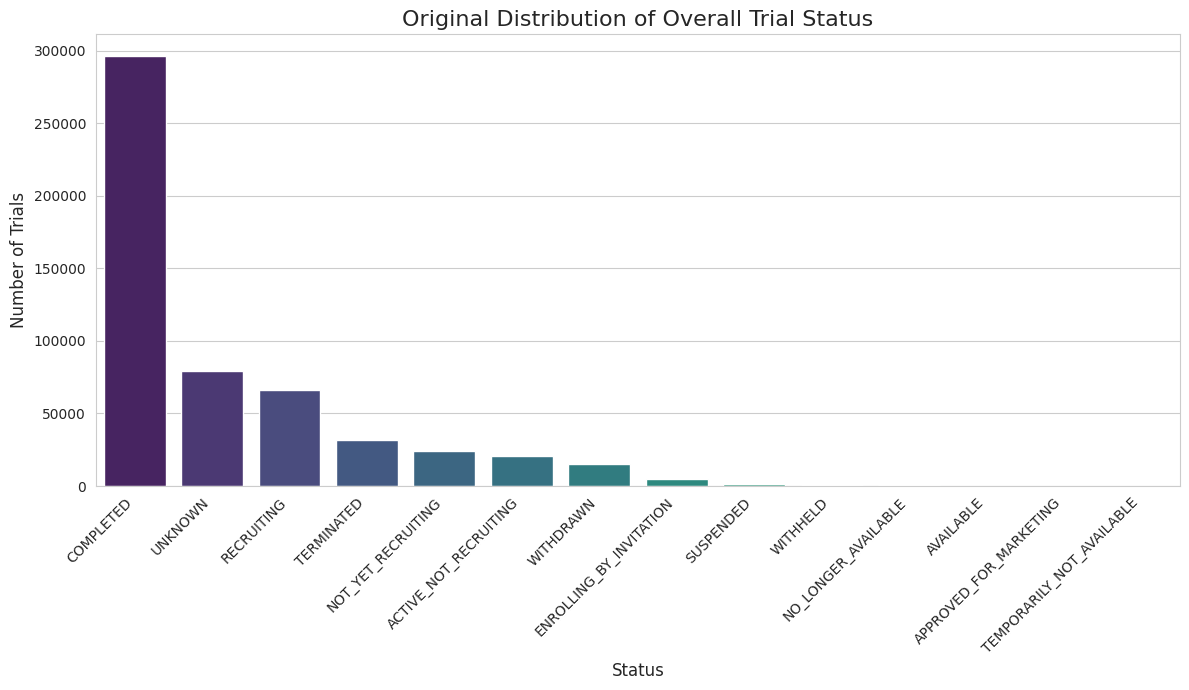

In [11]:
# Target Variable Analysis: overall_status

# First, we look at the original distribution of the 'overall_status' column.
print("--- Original Distribution of Trial Statuses ---")
status_counts = full_df['overall_status'].value_counts()
print(status_counts)

# Next we visualize the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Original Distribution of Overall Trial Status', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Defining the Binary Target for EDA

The `overall_status` column contains many different categories, where a lot of them are not definitive outcomes (e.g., "RECRUTING"). For our predictive task, we need a clear binary target representing **Success vs. Failure**. Based on the above plot, we define our classes as follows:

*   **Success (Target = 1):** Trials marked **"COMPLETED"**.
*   **Failure (Target = 0):** Trials that were stopped for definitive negative reasons. We include **"TERMINATED"**, **"WITHDRAWN"**, and **"SUSPENDED"**.

We will filter the dataset to these outcomes to create a clean target for our analysis.

--- Distribution of the Binary Target Variable ---
target
1    296549
0     48500
Name: count, dtype: int64


/tmp/ipython-input-1701962411.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=eda_filtered_df, palette="viridis")


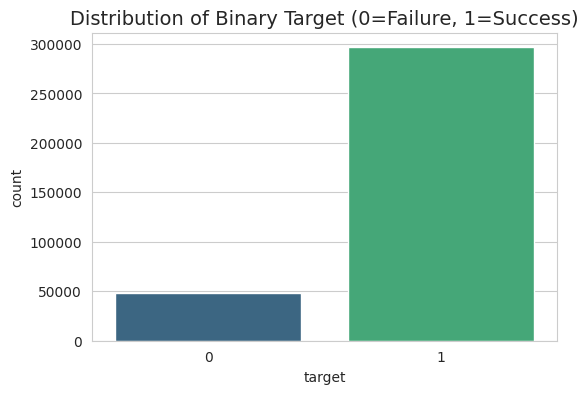

In [12]:
# Create a temporary filtered DataFrame for EDA visualization

success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
definitive_stati = success_stati + failure_stati

# Note: This filtered_df is for EDA purposes only.
# The final filtering for the model will happen within the preprocessing pipeline.
eda_filtered_df = full_df[full_df['overall_status'].isin(definitive_stati)].copy()
eda_filtered_df['target'] = eda_filtered_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# Visualize the new binary target distribution
print("--- Distribution of the Binary Target Variable ---")
print(eda_filtered_df['target'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=eda_filtered_df, palette="viridis")
plt.title('Distribution of Binary Target (0=Failure, 1=Success)', fontsize=14)
plt.show()

# Markdown analysis of the imbalance will go in the final EDA conclusion.

In [13]:
# Missing Values Analysis

structured_features = [
    'phases', 'study_type', 'enrollment_count',
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age'
]

missing_values = eda_filtered_df[structured_features].isnull().sum()
missing_percentage = (missing_values / len(eda_filtered_df)) * 100

print("--- Percentage of Missing Values in Key Features ---")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

--- Percentage of Missing Values in Key Features ---
maximum_age        46.71
phases             20.69
minimum_age         6.54
enrollment_count    1.24
sex                 0.09
dtype: float64


**Interpretation:**
The missing value analysis reveals several different frequencies of missing values, each with their own set of solutions or challenges:
*   `sex` and `enrollment_count` have very few missing values (<2%), making it safe to simply drop these rows in our processing pipeline.
*   `phases`, `minimum_age`, and `maximum_age` have a moderate to high percentage of missing data (6% to 47%). For these, we will need to use an imputation strategy (e.g., filling with "Unknown" for categoricals or the median for numericals) to avoid losing a significant portion of our dataset. This is the info we needed to design our preprocessing functions.

--- Distribution of Trial Phases ---


/tmp/ipython-input-2501590601.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='viridis')


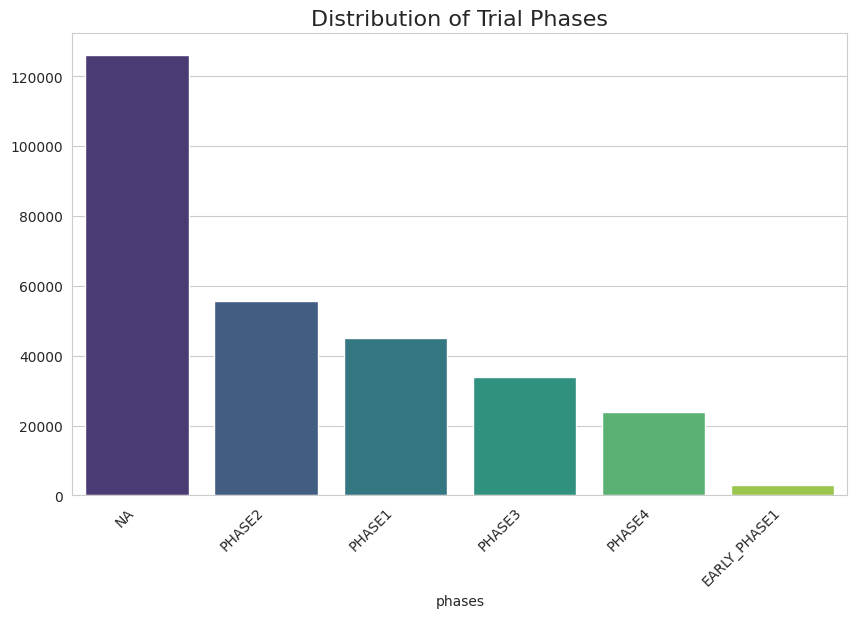

/tmp/ipython-input-2501590601.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
/tmp/ipython-input-2501590601.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
/tmp/ipython-input-2501590601.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viri

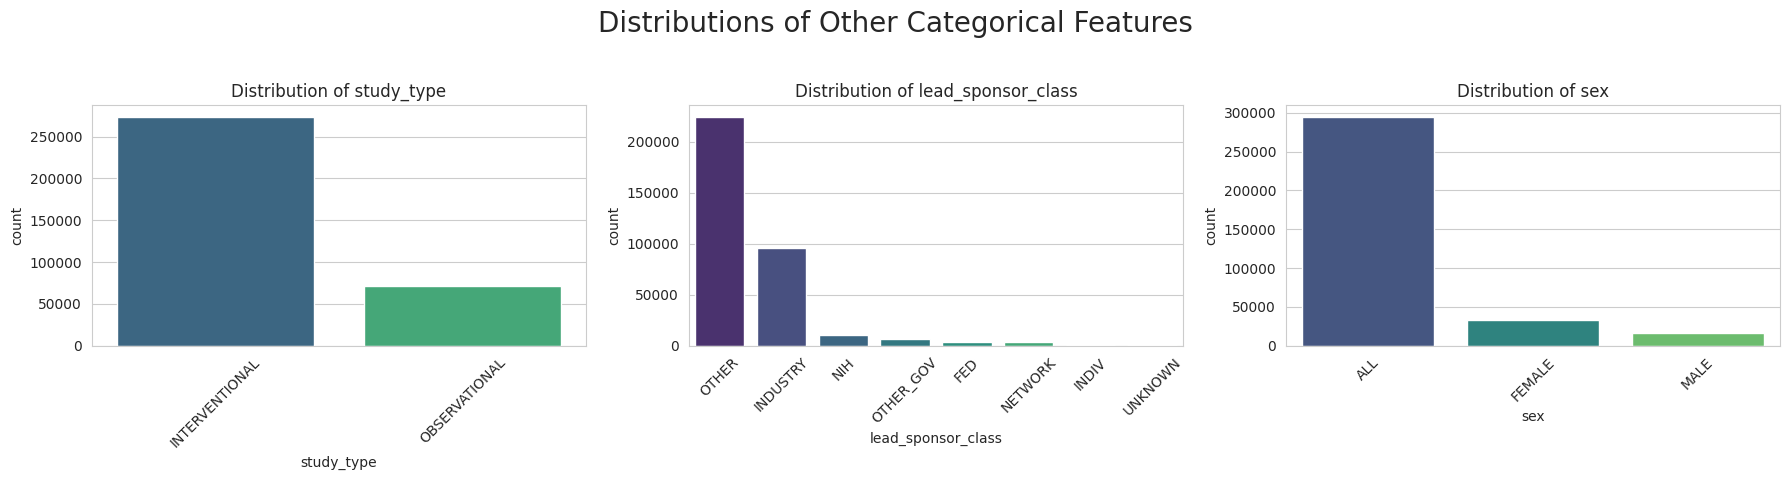

In [14]:
# Categorical Feature Distributions

# 1. 'phases' column (which contains lists/ndarrays)
print("--- Distribution of Trial Phases ---")
phase_counts = eda_filtered_df['phases'].explode().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='viridis')
plt.title('Distribution of Trial Phases', fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.show()

# 2. Other categorical features
simple_categorical_features = ['study_type', 'lead_sponsor_class', 'sex']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Other Categorical Features', fontsize=20)
axes = axes.flatten()
for i, feature in enumerate(simple_categorical_features):
    sns.countplot(x=feature, data=eda_filtered_df, ax=axes[i], palette='viridis', order=eda_filtered_df[feature].value_counts().index)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Interpretation:**

* **Phases:** The distribution is largely dominated by “NA” (Not Applicable) entries. We interpret these as corresponding to observational studies, which typically do not include defined phases. This category is therefore meaningful in itself, rather than simply representing missing data.
* **Sponsor:** The `lead_sponsor_class` feature is very skewed toward “OTHER.” While this limits its immediate interpretability, it still helps distinguish between major sponsor types such as “INDUSTRY” and “NIH.” A more granular manual grouping of these could potentially yield better insights. However, we hypothesize that our Multimodal Fusion Model will captures some of this institutional nuance implicitly through the trial summaries (embeddings), reducing the need for explicit manual feature engineering.
* **Study Type & Sex:** These features are imbalanced, reflecting the reality of clinical research (more interventional studies, most open to all sexes). This is not a data problem, but rather a real-world pattern our model can learn from.


In [15]:
# Numerical Feature Analysis

numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age']

# 1. Check data types and summary statistics
print("--- Data Types of Numerical Features ---")
print(eda_filtered_df[numerical_features].dtypes)
print("\n--- Summary Statistics for Numerical Features ---")
display(eda_filtered_df[numerical_features].describe())

--- Data Types of Numerical Features ---
enrollment_count    float64
minimum_age         float64
maximum_age         float64
dtype: object

--- Summary Statistics for Numerical Features ---


,enrollment_count,minimum_age,maximum_age
count,340763.00,322491.00,183888.00
mean,4124.89,20.08,58.63
std,398103.93,11.27,31.16
min,0.00,0.00,1.00
25%,24.00,18.00,45.00
50%,60.00,18.00,65.00
75%,159.00,18.00,75.00
max,188814085.00,730.00,6569.00


**Interpretation of Statistics:**
The summary statistics table is highly revealing:
*   **Skewness:** For all three features, the `mean` is significantly different from the `median` (50%), indicating strong skewness. `enrollment_count` shows the most extreme right skew.
*   **Outliers/Data Quality:** The age columns contain clear data errors or extreme outliers, with a `max` value of 730 for `minimum_age` and 6569 for `maximum_age`.  Building on our findings from P2, where we identified biologically impossible outliers in the age columns (e.g., 6000 years), we have implemented a capping strategy in our preprocessing pipeline. We clip all ages to the [0, 120] range. This is particularly critical for the P3 Neural Network model, which relies on Z-score standardization and would otherwise be distorted by these extreme values.

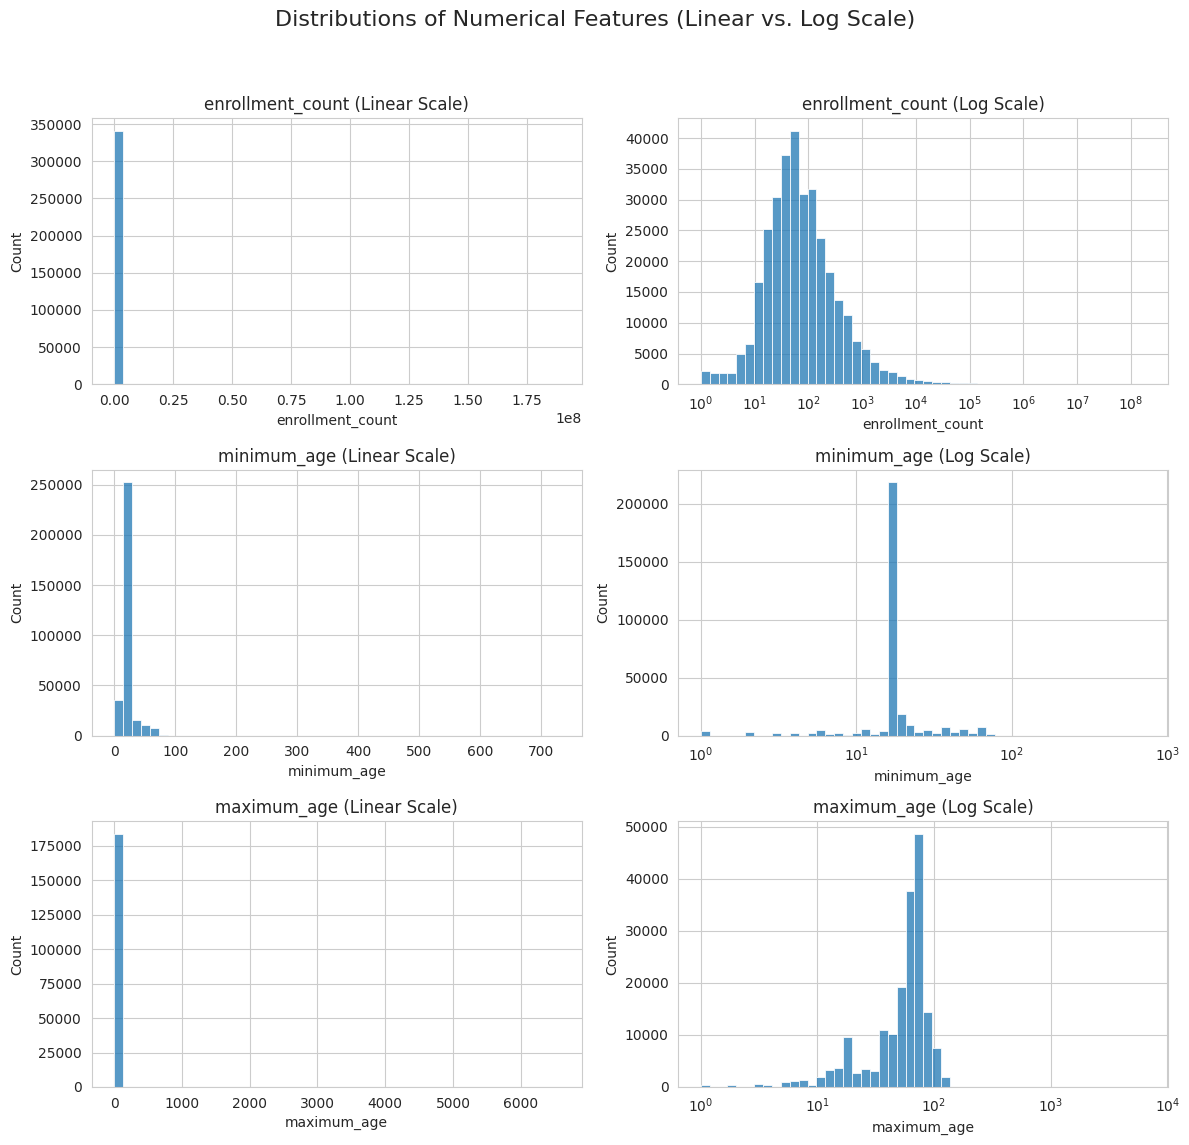

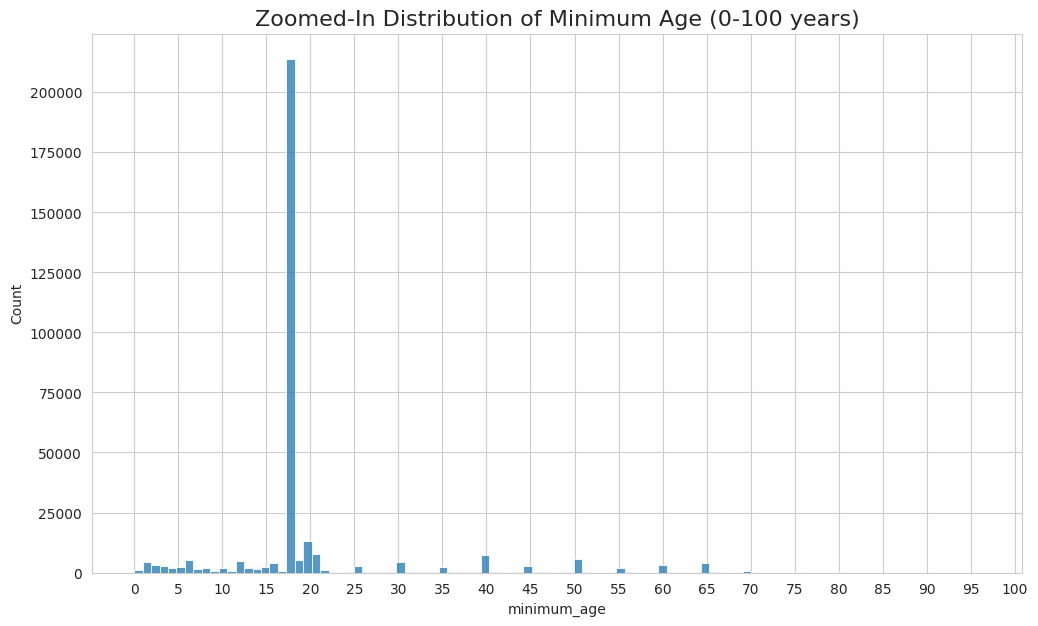

In [16]:
# Plot distributions (Linear vs. Log Scale)
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 12))
fig.suptitle('Distributions of Numerical Features (Linear vs. Log Scale)', fontsize=16)
for i, feature in enumerate(numerical_features):
    sns.histplot(eda_filtered_df[feature], bins=50, kde=False, ax=axes[i, 0]).set_title(f'{feature} (Linear Scale)')
    sns.histplot(eda_filtered_df[feature], bins=50, kde=False, ax=axes[i, 1], log_scale=True).set_title(f'{feature} (Log Scale)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# "Zoomed-in" plot for minimum_age
zoomed_df = eda_filtered_df[eda_filtered_df['minimum_age'] <= 100]
plt.figure(figsize=(12, 7))
sns.histplot(data=zoomed_df, x='minimum_age', bins=100)
plt.title('Zoomed-In Distribution of Minimum Age (0-100 years)', fontsize=16)
plt.xticks(ticks=range(0, 101, 5))
plt.show()

**Interpretation of Plots:**
*   The log-scaled plots confirm the right-skew of `enrollment_count` and `maximum_age`.
*   The zoomed-in plot for `minimum_age` tells us the most. It proves that this feature does not have a smooth distribution and instead acts like a combination of a smooth distribution at low ages and a **categorical variable**, dominated by specific values like 0, 18, and other "round number" age cutoffs (40, 50, 65). This is likely because many studies aimed at lower age groups have specific age requirements where a few years' difference is developmentally significant (e.g., 13 vs. 16 years old), while studies targeting older adults often use broader, round-number cutoffs where the difference between 40 and 42 is less critical. We considered binning this feature, but we chose to leave it as a continuous numerical variable (capped at 120) to allow the non-linear models (Random Forest and Neural Network) to learn the precise age-related boundaries without the information loss associated with manual binning.

## EDA Conclution

Our exploratory analysis has provided several good insights that directly inform our project's next steps:
1.  **A Clear (but Imbalanced) Target:** We have successfully defined a binary target variable ("Success" vs. "Failure"), but its severe class imbalance is the primary challenge we must address.
2.  **Informative (but Messy) Features:** The structured features show clear patterns and distributions that we **hypothesize contain predictive signals** (e.g., the difference in `phases` or `study_type`). However, they also suffer from missing data, skewness, and data quality issues (e.g., age outliers). Our preprocessing pipeline must be designed to handle these issues robustly to effectively test this hypothesis.

With this new and deeper understanding of the data, we are now ready to move on to the formal data preparation and modeling phase.

#  Feature Engineering: Text Embeddings

One of the hypothesis of this project is that the structured metadata alone (e.g., Phase, Enrollment Count) is not enough to capture the complexity of clinical trial failure. The "scientific logic" of a trial is often buried in its textual descriptions.

### Embeddings Generation Strategy
While the original dataset documentation stated that it included pre-computed embeddings, they were absent from the dataset files. So, we engineered these features manually to enable our Multimodal approach.

We utilized the **`thomas-sounack/BioClinical-ModernBERT-base`** model, a transformer architecture pre-trained specifically on biomedical and clinical text. This model was chosen for its ability to capture domain-specific semantic nuances that generic BERT models might miss, as well as being reccomended by the dataset creators. We generated embeddings for two key text columns:
1.  **`brief_summary`**: Captures the trial's design and intent.
2.  **`eligibility_criteria`**: Captures the inclusion/exclusion logic, often a key determinant of recruitment failure.

Each text field was converted into a **768-dimensional vector**, resulting in a combined **1536-dimensional feature space** for the text modality.

### Offline Computation and Sharding
Due to the computational expense of processing ~540,000 trials through a Transformer model, this step was performed offline using a GPU-accelerated environment. To manage memory constraints and prevent timeouts, we adopted a **sharding strategy**:
1.  **Sharding:** The raw dataset was split into manageable chunks (shards).
2.  **Processing:** Each shard was processed individually using the `embedding-generation.ipynb` notebook, found in the project repository.
3.  **Merging:** The processed shards were reassembled into the final dataset using a dedicated script, `combine.py`, found in the archive folder of the repository.

The resulting dataset, containing both the original structured data and the new high-dimensional embeddings, was saved as a Parquet file for efficient loading.

# Data Loading & Splitting

With the addition of the 1536-dimensional embeddings, the memory footprint of the full dataset (approx. 540,000 trials) exceeds the RAM limits of standard cloud environments when loaded as a single Pandas DataFrame (12 GB in the base Colab). Trying to load the file and perform a standard `train_test_split` in-memory results in immediate runtime crashes.

To fix this, we performed the data partitioning in a dedicated upstream notebook (`splits.ipynb`). We utilized **Polars**, a high-performance dataframe library, to efficiently shuffle and split the data while minimizing memory overhead.

The data was partitioned into three distinct sets using **stratified sampling** to maintain the original class imbalance across all splits:
1.  **Training Set (70%):** Used for model training and balancing.
2.  **Validation Set (15%):** Used for hyperparameter tuning and early stopping during neural network training.
3.  **Test Set (15%):** A strict hold-out set used exclusively for final evaluation.

By physically separating these subsets into individual Parquet files, we achieve two goals: effective memory management (loading only what is needed) and a guarantee of zero data leakage, as the test set remains isolated from all preprocessing and balancing steps.

In [17]:
# Load the Full Parquet files (Train/Val/Test) from Drive.

# 1. Define the path where the files are located
# This should match the 'output_dir' from the Polars script we ran
base_path = '/content/drive/My Drive/clinical_trials_embeddings/'

print(f"Loading datasets from: {base_path}")

# 2. Load TRAIN set
# We add memory_map=True to help Colab manage RAM
X_train = pd.read_parquet(base_path + 'train_set.parquet', memory_map=True)
y_train = X_train['overall_status']

# 3. Load VALIDATION set
X_val = pd.read_parquet(base_path + 'val_set.parquet', memory_map=True)
y_val = X_val['overall_status']

# 4. Load TEST set
# Tip: If your Colab session crashes due to RAM here, comment out the next two lines
# and only load the test set at the very end of your notebook when you need it.
X_test = pd.read_parquet(base_path + 'test_set.parquet', memory_map=True)
y_test = X_test['overall_status']

print(f"Final Shapes:")
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Loading datasets from: /content/drive/My Drive/clinical_trials_embeddings/
Final Shapes:
Train: (379313, 10)
Val:   (81299, 10)
Test:  (81285, 10)


In [18]:
# RAM OPTIMIZATION: Separate Structured from Embeddings

# 1. Define the columns we need for structured preprocessing
# (These must match what's in your utils.py)
structured_cols = [
    'phases', 'study_type', 'enrollment_count',
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age'
]

# 2. Create lightweight dataframes for structured processing
# We keep the index to align them later!
print("Separating structured data...")
X_train_struct_raw = X_train[structured_cols].copy()
X_val_struct_raw = X_val[structured_cols].copy()
X_test_struct_raw = X_test[structured_cols].copy()

# 3. Create Target variables
# (You already did this, but ensuring they are separate series helps)
y_train = X_train['overall_status']
y_val = X_val['overall_status']
y_test = X_test['overall_status']

print("Structured data separated.")

Separating structured data...
Structured data separated.


## Split before balancing

An important methodological decision we made for this pipeline is the strict separation of **Data Splitting** and **Data Balancing**.

In the following sections, we will employ a downsampling strategy to address class imbalance. However, it is important that this balancing is applied **exclusively to the Training set**. The Validation and Test sets must remain in their original, imbalanced state for two reasons:

1.  **Reflecting Real-World Distributions:** The prevalence of trial failure in our test dataset is approximately 14%. If we were to balance the Test set (making it 50% failure), our evaluation metrics—particularly Precision and F1-Score—would be artificially inflated and would not reflect the model's performance in a real deployment scenario.
2.  **Preventing Data Leakage:** Modifying the distribution of the test data constitutes a form of data leakage, where the evaluation conditions are engineered to suit the model rather than the reality of the problem.

Therefore, throughout the rest of this notebook, you will observe that while the training data is downsampled to a 50/50 ratio to facilitate feature learning, all reported performance metrics are derived from the original, highly imbalanced Test set.

## Structured Data Preprocessing Pipeline

To make sure our preprocessing is modular, reusable, and consistently applied, we have created two functions, stored in a separate `utils.py` file. This `fit`/`transform` paradigm is a standard best practice that prevents data leakage from the test set into the training process.

### Utility Functions
1.  **`fit_and_preprocess_train(train_df)`:** This function learns transformation parameters (like medians and scaling factors) exclusively from the training data and applies them. It returns a processed training DataFrame and a `transformation_rules` dictionary.
2.  **`transform_test_data(test_df, rules)`:** This function takes the test data and the `transformation_rules` dictionary and applies the already learned transformations, ensuring the test set is treated as unseen data.

### Detailed Preprocessing Steps
The pipeline implemented in our utility functions performs the following sequential operations on the structured data:

*   **1. Feature Selection:** It selects the seven structured features identified during EDA: `phases`, `study_type`, `enrollment_count`, `lead_sponsor_class`, `sex`, `minimum_age`, and `maximum_age`.
*   **2. Outcome Filtering:** It filters the dataset to only include trials with a definitive outcome ("COMPLETED", "TERMINATED", "WITHDRAWN", "SUSPENDED").
*   **3. Handling Missing Values & Outliers:**
    *   **Row Dropping:** Drops rows where `sex` or `enrollment_count` are missing (<2% of data).
    *   **Categorical Imputation:** Fills missing `NaN` values in `phases` with `"Unknown"`.
    *   **Numerical Imputation:** Fills missing `NaN` values in age columns with the training set median.
    *   **Outlier Capping:** Clips `minimum_age` and `maximum_age` to the range [0, 120] to prevent extreme outliers (e.g., 6000 years) from distorting the standardization process.
*   **4. One-Hot Encoding:** Converts categorical features into a numerical format. The encoder uses `handle_unknown='ignore'` to robustly handle unseen categories in the test set.
*   **5. Numerical Scaling:** Standardizes numerical features using a `StandardScaler` (mean=0, std=1) to ensure efficient training for the Neural Network.

In [19]:
# Preprocess Structured Data (Unbalanced)

# We need to temporarily attach the target to X_train_struct_raw
# because fit_and_preprocess_train expects it for filtering
X_train_struct_raw['overall_status'] = y_train

print("Preprocessing Unbalanced Train...")
processed_train_struct, rules = fit_and_preprocess_train(X_train_struct_raw)

# Now we prepare Val and Test for transformation
# We must attach 'overall_status' to them too because transform_test_data expects it
X_val_struct_raw['overall_status'] = y_val
X_test_struct_raw['overall_status'] = y_test

print("Preprocessing Val/Test...")
processed_val_struct = transform_test_data(X_val_struct_raw, rules)
processed_test_struct = transform_test_data(X_test_struct_raw, rules)

print("Structured preprocessing complete.")
print(f"Processed Train Shape: {processed_train_struct.shape}")

Preprocessing Unbalanced Train...
Dropped 3176 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.
Preprocessing Val/Test...
Test data transformed successfully using training set rules.
Test data transformed successfully using training set rules.
Structured preprocessing complete.
Processed Train Shape: (238237, 24)


# Baselines Phase 1: The Impact of Imbalance

To quantify the value of our proposed interventions (Data Balancing and Multimodal Fusion), we must first establish a baseline. In this phase, we train our baseline, uncombined models on the **raw, unbalanced training set** (approximately 86% Success / 14% Failure) and evaluate them on the unbalanced test set.

Our primary goal here is to show the baseline behavior of standard machine learning algorithms when faced with severe class imbalance: the tendency to maximize global accuracy by ignoring the minority class (the "Lazy Classifier" phenomenon).

### Model Selection Rationale: Random Forest
For both the Structured Data and the Text Embeddings, we utilize a **Random Forest Classifier** as our baseline. This choice is driven by specific requirements for each data modality:

*   **For Structured Metadata:** Clinical trial data involves complex, non-linear interactions between features (e.g., the risk associated with a specific *Sponsor* type might depend heavily on the *Phase* of the trial). Random Forests are the industry standard for tabular data, offering robustness to outliers and the ability to capture these non-linear decision boundaries without extensive hyperparameter tuning.

*   **For Text Embeddings:** In our preliminary P2 analysis, we attempted to classify trial outcomes using linear models (Logistic Regression) on the embeddings. These models failed to achieve meaningful predictive power (F1-scores < 0.10), suggesting that the relationship between the semantic embedding space and trial success is highly non-linear. Consequently, we require a baseline with sufficient capacity to model complex manifolds in the 1536-dimensional feature space.

In the following cells, we train these baselines and analyze their Confusion Matrices to diagnose the specific failure modes caused by the class imbalance.

--- Final Shapes for Structured Model (Unbalanced) ---
Shape of X_train: (238237, 23)
Shape of y_train: (238237,)
Shape of X_test:  (51052, 23)

Training Random Forest on UNBALANCED structured data...
Training complete.

Making predictions on Test Set...

--- Baseline 1: Structured Metadata (Unbalanced) ---
              precision    recall  f1-score   support

     Failure       0.87      0.44      0.58      7240
     Success       0.91      0.99      0.95     43812

    accuracy                           0.91     51052
   macro avg       0.89      0.71      0.77     51052
weighted avg       0.91      0.91      0.90     51052



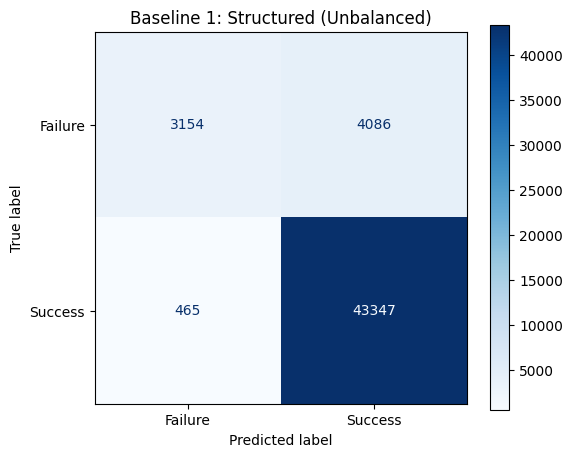

In [20]:
# Run Baseline 1 (Structured Unbalanced).

# Use the specific variables we created in "Preprocess Structured Data (Unbalanced)"
# processed_train_struct contains the target column 'target'
X_train_s = processed_train_struct.drop('target', axis=1)
y_train_s = processed_train_struct['target']

# We use the TEST set here for the final report numbers
X_test_s = processed_test_struct.drop('target', axis=1)
y_test_s = processed_test_struct['target']

# --- Sanity Check ---
print("--- Final Shapes for Structured Model (Unbalanced) ---")
print(f"Shape of X_train: {X_train_s.shape}")
print(f"Shape of y_train: {y_train_s.shape}")
print(f"Shape of X_test:  {X_test_s.shape}")

# --- 3.2. Train the Random Forest Classifier ---

print("\nTraining Random Forest on UNBALANCED structured data...")
# Limiting max_depth to 15 to prevent it from memorizing the massive dataset
# (and to save RAM/Time)
rf_struct = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_struct.fit(X_train_s, y_train_s)
print("Training complete.")

# --- 3.3. Evaluate ---
print("\nMaking predictions on Test Set...")
y_pred_s = rf_struct.predict(X_test_s)

print("\n--- Baseline 1: Structured Metadata (Unbalanced) ---")
print(classification_report(y_test_s, y_pred_s, target_names=['Failure', 'Success']))

# Plot Confusion Matrix
with plt.style.context('default'):
  fig, ax = plt.subplots(figsize=(6, 5))
  ConfusionMatrixDisplay.from_predictions(
      y_test_s,
      y_pred_s,
      ax=ax,
      display_labels=['Failure', 'Success'],
      cmap='Blues'
  )
  plt.title("Baseline 1: Structured (Unbalanced)")
  plt.show()

Preparing Training Data...
Processing 241413 rows...
Training Matrix Shape: (241413, 1536)
Training Random Forest on UNBALANCED Embeddings...
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   35.9s


building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.6min finished


Training complete.
Preparing Test Data...
Processing 51758 rows...
Making predictions...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.2s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Baseline 2: Embeddings (Unbalanced) ---
              precision    recall  f1-score   support

     Failure       0.00      0.00      0.00      7275
     Success       0.86      1.00      0.92     44483

    accuracy                           0.86     51758
   macro avg       0.43      0.50      0.46     51758
weighted avg       0.74      0.86      0.79     51758



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


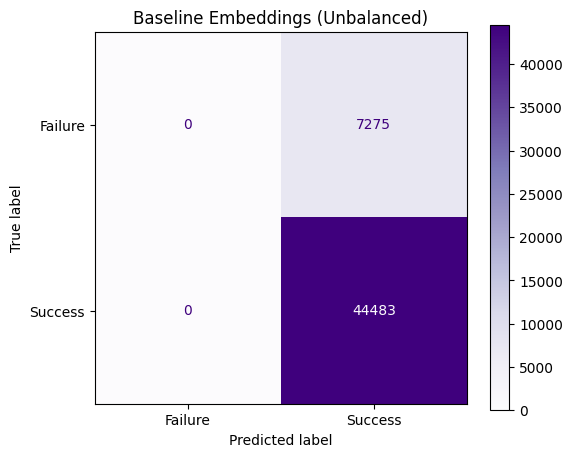

14408

In [21]:
# Run Baseline 2 (Embeddings Unbalanced).

def process_embeddings_for_baseline(df):
    """
    1. Filters for definitive outcomes.
    2. Stacks and concatenates the two embedding columns into a single matrix.
    Returns: X (numpy array), y (pandas series)
    """
    # 1. Filter Target
    success = ["COMPLETED"]
    failure = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
    definitive = success + failure

    df_clean = df[df['overall_status'].isin(definitive)].copy()
    y_clean = df_clean['overall_status'].apply(lambda x: 1 if x in success else 0)

    # 2. Stack Embeddings
    print(f"Processing {len(df_clean)} rows...")
    summary_emb = np.vstack(df_clean['brief_summary_embedding'].values)
    criteria_emb = np.vstack(df_clean['eligibility_criteria_embedding'].values)

    # 3. Concatenate
    X_clean = np.concatenate([summary_emb, criteria_emb], axis=1)

    return X_clean, y_clean

# --- Main Execution ---

# 1. Prepare Data
print("Preparing Training Data...")
X_train_emb, y_train_emb = process_embeddings_for_baseline(X_train)

print(f"Training Matrix Shape: {X_train_emb.shape}")

# 2. Train Model
print("Training Random Forest on UNBALANCED Embeddings...")
rf_emb = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=2
)
rf_emb.fit(X_train_emb, y_train_emb)
print("Training complete.")

# 3. Cleanup Training Data (Optional with 53GB, but good practice)
del X_train_emb, y_train_emb
gc.collect()

# 4. Prepare Test Data
print("Preparing Test Data...")
X_test_emb, y_test_emb = process_embeddings_for_baseline(X_test)

# 5. Evaluate
print("Making predictions...")
y_pred_emb = rf_emb.predict(X_test_emb)

print("\n--- Baseline 2: Embeddings (Unbalanced) ---")
print(classification_report(y_test_emb, y_pred_emb, target_names=['Failure', 'Success']))

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb,
        y_pred_emb,
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Purples'
    )
    plt.title("Baseline Embeddings (Unbalanced)")
    plt.show()

# Final Cleanup
del X_test_emb, y_test_emb, rf_emb
gc.collect()

## Discussion:

The results from our initial baselines showcase the challenges of training on severely imbalanced data (approx. 86% Success vs. 14% Failure).

*   **Baseline 1 (Structured):** While achieving a high accuracy of **91%**, the model missed **58%** of all actual failures (Recall: 0.44).
*   **Baseline 2 (Embeddings):** The issue is even more extreme here. Despite an accuracy of **86%**, the model failed to identify a **single failed trial** (Recall: 0.00).

These models exhibit the "Lazy Classifier" phenomenon: they maximize their global accuracy by simply defaulting to the majority class ("Success"). In a clinical context, this is a critical failure mode; a model that never flags a risky trial is functionally useless, regardless of its accuracy.

**Conclusion:** The predictive signal for failure exists, but it is being overwhelmed by the majority class. To uncover this signal, we must alter the training distribution. In the next section, we implement a **Downsampling Strategy** to force the models to learn the characteristics of failed trials, accepting that this will likely increase False Positives (lower Precision) in exchange for the necessary Recall.


# Data Balancing Strategy

As we showed in the previous section, the severe class imbalance caused our baseline models to default to a "majority class" prediction strategy, resulting in a Failure Recall of 0.00 for the embeddings model.

### Random Downsampling
We implement a **Random Downsampling** strategy using the `balance_raw_data` utility function. This function performs the following steps:
1.  **Separation:** It isolates the minority class (Failures) and the majority class (Successes) within the training data.
2.  **Resampling:** It randomly samples instances from the majority class (without replacement) until the count matches the minority class exactly.
3.  **Shuffling:** The two sets are concatenated and shuffled to create a perfectly balanced (50/50) training set.

**Methodological Constraint:** This balancing is applied exclusively to the Training set. The Validation and Test sets remain in their original, imbalanced state to ensuring that our evaluation metrics reflect the model's performance in a real-world scenario.

In [22]:
# Load and balance

print("Reloading X_train for balancing...")
# We need to reload because we might have deleted parts of it to save RAM
# Ensure this path matches your setup
base_path = '/content/drive/My Drive/clinical_trials_embeddings/'
X_train = pd.read_parquet(base_path + 'train_set.parquet', memory_map=True)

print("Balancing Training Data...")
# This uses your function from utils.py
X_train_balanced = balance_raw_data(X_train)

# Clean up the huge unbalanced file immediately to save RAM
del X_train
gc.collect()

print(f"Balanced Train Shape: {X_train_balanced.shape}")

Reloading X_train for balancing...
Balancing Training Data...
Original counts - Success: 207420, Failure: 33993
Balanced counts - Success: 33993, Failure: 33993
Balanced Train Shape: (67986, 11)


#  Baselines Phase 2: Recovering the Signal

We now retrain on balanced data to prioritize recall

Preprocessing BALANCED Structured Data...
Dropped 720 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.
Applying Balanced Rules to Val/Test...
Test data transformed successfully using training set rules.
Test data transformed successfully using training set rules.
Training RF on BALANCED Structured Data...
Evaluating...

--- Baseline 3: Structured Metadata (Balanced) ---
              precision    recall  f1-score   support

     Failure       0.46      0.66      0.54      7240
     Success       0.94      0.87      0.90     43812

    accuracy                           0.84     51052
   macro avg       0.70      0.77      0.72     51052
weighted avg       0.87      0.84      0.85     51052



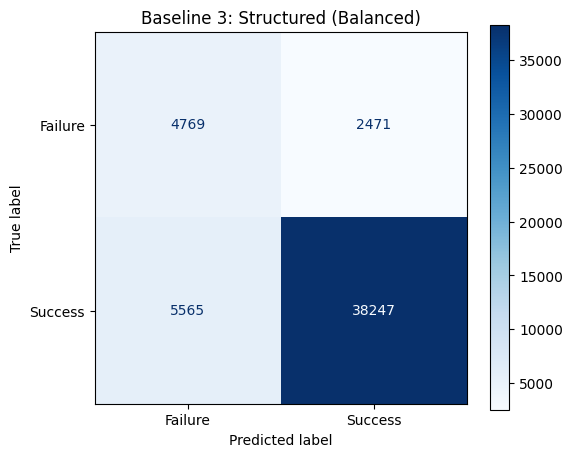

Cleanup done. Processed dataframes retained for Fusion Model.


In [23]:
# Run Baseline 3 (Structured Balanced).

# --- 1. Define Columns ---
structured_cols = [
    'phases', 'study_type', 'enrollment_count',
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age', 'overall_status'
]

# --- 2. Preprocess Balanced Structured Data (TRAIN) ---
print("Preprocessing BALANCED Structured Data...")

# Create lightweight raw subset
X_train_bal_struct_raw = X_train_balanced[structured_cols].copy()

# Fit & Transform (Learn the 'Balanced Rules')
# IMPORTANT: We KEEP 'processed_train_bal_struct' for the Fusion Model!
processed_train_bal_struct, balanced_rules = fit_and_preprocess_train(X_train_bal_struct_raw)

# --- 3. Preprocess VAL and TEST (using Balanced Rules) ---
print("Applying Balanced Rules to Val/Test...")

# We prepare these NOW so they are ready for the Fusion Model later
# Ensure X_val and X_test are loaded in memory
X_val_struct_raw = X_val[structured_cols].copy()
X_test_struct_raw = X_test[structured_cols].copy()

# Transform
processed_val_struct = transform_test_data(X_val_struct_raw, balanced_rules)
processed_test_struct = transform_test_data(X_test_struct_raw, balanced_rules)

# --- 4. Baseline 3: Train & Evaluate ---
# Prepare X/y for Scikit-Learn
X_train_sb = processed_train_bal_struct.drop('target', axis=1)
y_train_sb = processed_train_bal_struct['target']

X_test_sb = processed_test_struct.drop('target', axis=1)
y_test_sb = processed_test_struct['target']

print("Training RF on BALANCED Structured Data...")
rf_struct_bal = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_struct_bal.fit(X_train_sb, y_train_sb)

print("Evaluating...")
y_pred_sb = rf_struct_bal.predict(X_test_sb)

print("\n--- Baseline 3: Structured Metadata (Balanced) ---")
print(classification_report(y_test_sb, y_pred_sb, target_names=['Failure', 'Success']))

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_sb,
        y_pred_sb,
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Blues'
    )
    plt.title("Baseline 3: Structured (Balanced)")
    plt.show()

# --- 5. Cleanup ---
# We delete the RAW subsets and the SKLEARN inputs to save RAM.
# But we KEEP 'processed_train_bal_struct', 'processed_val_struct', 'processed_test_struct'
del X_train_bal_struct_raw, X_val_struct_raw, X_test_struct_raw
del X_train_sb, y_train_sb, X_test_sb, y_test_sb, rf_struct_bal
gc.collect()

print("Cleanup done. Processed dataframes retained for Fusion Model.")


Preparing BALANCED Training Embeddings...
Processing 67986 rows...
Training RF on BALANCED Embeddings...
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    9.1s


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   39.3s finished


Preparing Unbalanced Test Data...
Processing 51758 rows...
Evaluating...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.2s finished



--- Baseline 4: Embeddings (Balanced) ---
              precision    recall  f1-score   support

     Failure       0.24      0.65      0.35      7275
     Success       0.92      0.66      0.77     44483

    accuracy                           0.66     51758
   macro avg       0.58      0.65      0.56     51758
weighted avg       0.82      0.66      0.71     51758



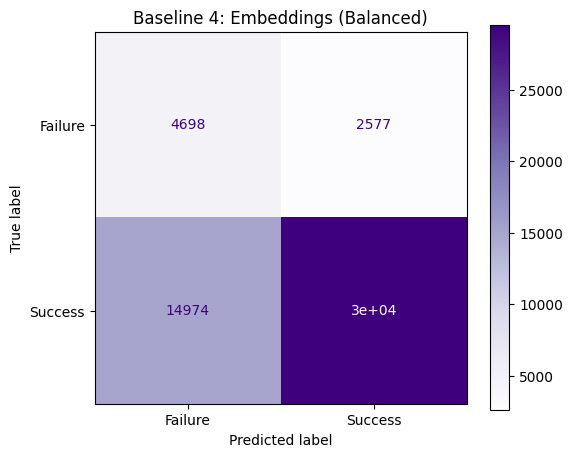

4501

In [24]:
# Run Baseline 4 (Embeddings Balanced).

# --- 1. Prepare Balanced Embeddings (TRAIN) ---
print("Preparing BALANCED Training Embeddings...")

# Reuse the helper function from Baseline 2
# It handles stacking, concatenating, and target extraction automatically
X_train_emb_bal, y_train_emb_bal = process_embeddings_for_baseline(X_train_balanced)

# --- 2. Train Model ---
print("Training RF on BALANCED Embeddings...")
# verbose=2 is good here so you know it's working
rf_emb_bal = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, verbose=2)
rf_emb_bal.fit(X_train_emb_bal, y_train_emb_bal)

# Cleanup Train vars to save RAM for the Fusion Model
del X_train_emb_bal, y_train_emb_bal
gc.collect()

# --- 3. Evaluate on Unbalanced TEST Set ---
print("Preparing Unbalanced Test Data...")

# Reuse helper function again
# (Note: X_test is likely already in memory from previous steps)
X_test_emb, y_test_emb = process_embeddings_for_baseline(X_test)

print("Evaluating...")
y_pred_emb_bal = rf_emb_bal.predict(X_test_emb)

print("\n--- Baseline 4: Embeddings (Balanced) ---")
print(classification_report(y_test_emb, y_pred_emb_bal, target_names=['Failure', 'Success']))

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb,
        y_pred_emb_bal,
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Purples'
    )
    plt.title("Baseline 4: Embeddings (Balanced)")
    plt.show()

# --- 4. Final Cleanup ---
del X_test_emb, y_test_emb, rf_emb_bal
gc.collect()


## Discussion

The results from Baselines 1 through 4 provide a the confirmation of our hypothesis regarding class imbalance.

The downsampling strategy (Baselines 3 and 4) successfully forced the models to learn the characteristics of the minority class. The impact is most visible in the **Failure Recall**:
*   **Structured Recall:** Improved from 0.44 $\to$ **0.66**.
*   **Embeddings Recall:** Improved from 0.00 $\to$ **0.65**.

**Trade-off**
This improvement in sensitivity came at a calculated cost.
*   **Precision Drop:** The Balanced Embeddings model (Baseline 4) dropped to a precision of **0.24**, indicating it produces a high number of False Positives (predicting failure when the trial actually succeeds).
*   **Accuracy Drop:** The overall accuracy of the Embeddings model dropped from 86% to **66%**.

**Conclusion:** While the balanced models are "noisier" (lower precision), they have successfully recovered the predictive signal for trial failure. We have proven that **both** the structured metadata and the text embeddings contain independent signals capable of detecting ~65% of failures. In the next section, we hypothesize that combining these two distinct signals in a **Multimodal Fusion Model** will maintain this high recall while potentially stabilizing predictions.

# The Multimodal Fusion Model (Intermediate Fusion)

To leverage the complementary strengths of the structured metadata and the text embeddings, we designed a custom **Intermediate Fusion (Late-Stage) Neural Network**.

### Architectural Rationale
A naive approach would be "Early Fusion," where the 1536-dimensional embeddings and the ~23-dimensional structured features are concatenated at the input level. However, this is suboptimal for two reasons:
1.  **Dimensionality Mismatch:** The massive embedding vector would mathematically drown out the signal from the small structured feature set.
2.  **Modality Independence:** The logic required to interpret a "Sponsor Type" is vastly different from the logic required to interpret "semantic similarity in eligibility criteria."

Instead, we utilize **Intermediate Fusion**. We construct two separate "branches" (sub-networks) to process each modality independently, extracting a dense latent representation for each *before* combining them.

### Network Topology
The architecture consists of three distinct components:

1.  **The Structured Branch:**
    *   **Input:** ~23 standardized features.
    *   **Transformation:** Projects the features into a higher-dimensional space (64 units) with `ReLU` activation and `BatchNorm`.
    *   **Goal:** To capture non-linear interactions between trial design parameters (e.g., Phase vs. Enrollment).

2.  **The Text Branch:**
    *   **Input:** 1536-dimensional BioBERT embeddings.
    *   **Transformation:** Acts as a **Bottleneck**. It compresses the high-dimensional input down to a dense vector (1536 to 512 to 128).
    *   **Regularization:** High Dropout (0.5) is applied here to prevent the model from overfitting on the complex text features.
    *   **Goal:** To distill the "semantic essence" of the trial description into a compact, informative vector that doesn't overwhelm the structured data.

3.  **The Fusion Head:**
    *   **Mechanism:** The outputs of the two branches (64d + 128d) are concatenated into a single 192-dimensional multimodal vector.
    *   **Classification:** A final fully connected layer maps this combined vector to a single logit, representing the probability of trial success.

This architecture ensures that the model learns to weigh the *scientific context* (text) and the *operational constraints* (metadata) appropriately before making a final prediction.

In [27]:
# Multimodal training

# Import helpers from the utils file. REMEMBER to have it in the google drive directory for this Colab notebook!!
from utils import ClinicalTrialDataset, train_model

# --- 1. Define the Network Architecture (Essential Logic) ---
class MultimodalNet(nn.Module):
    def __init__(self, structured_input_dim, embedding_input_dim=1536):
        super(MultimodalNet, self).__init__()

        # Branch 1: Structured Data
        self.struct_layer1 = nn.Linear(structured_input_dim, 64)
        self.struct_bn1 = nn.BatchNorm1d(64)
        self.struct_dropout = nn.Dropout(0.3)

        # Branch 2: Text Embeddings
        self.text_layer1 = nn.Linear(embedding_input_dim, 512)
        self.text_bn1 = nn.BatchNorm1d(512)
        self.text_dropout1 = nn.Dropout(0.5)

        self.text_layer2 = nn.Linear(512, 128)
        self.text_bn2 = nn.BatchNorm1d(128)

        # Fusion
        fusion_dim = 64 + 128

        # Head
        self.fc_final = nn.Linear(fusion_dim, 64)
        self.output = nn.Linear(64, 1)

    def forward(self, x_structured, x_text):
        # Structured Path
        out_s = self.struct_layer1(x_structured)
        out_s = self.struct_bn1(out_s)
        out_s = F.relu(out_s)
        out_s = self.struct_dropout(out_s)

        # Text Path
        out_t = self.text_layer1(x_text)
        out_t = self.text_bn1(out_t)
        out_t = F.relu(out_t)
        out_t = self.text_dropout1(out_t)

        out_t = self.text_layer2(out_t)
        out_t = self.text_bn2(out_t)
        out_t = F.relu(out_t)

        # Concatenate
        combined = torch.cat((out_s, out_t), dim=1)

        # Final Prediction
        out = self.fc_final(combined)
        out = F.relu(out)
        logits = self.output(out)
        return logits

# --- 2. Prepare Data for PyTorch ---
print("Preparing Tensors for Fusion Model...")

# Helper to stack embeddings and align structured data
def prepare_tensors(processed_df, raw_df_with_embeddings):
    # 1. Get Structured Features (Drop target)
    X_struct = processed_df.drop('target', axis=1).values.astype(np.float32)

    # 2. Get Targets
    y = processed_df['target'].values.astype(np.float32)

    # 3. Get Embeddings (Align by Index)
    # We filter the raw df to match the processed df's index
    aligned_raw = raw_df_with_embeddings.loc[processed_df.index]

    emb_summary = np.vstack(aligned_raw['brief_summary_embedding'].values)
    emb_criteria = np.vstack(aligned_raw['eligibility_criteria_embedding'].values)
    X_emb = np.concatenate([emb_summary, emb_criteria], axis=1).astype(np.float32)

    return X_struct, X_emb, y

# A. Prepare TRAIN (Balanced)
# processed_train_bal_struct came from Baseline 3
# X_train_balanced came from Step 1 of Phase 2
train_struct, train_emb, train_labels = prepare_tensors(processed_train_bal_struct, X_train_balanced)

# B. Prepare VAL (Unbalanced) - For monitoring
# processed_val_struct came from Baseline 1 (Step 3)
# X_val came from Step 2.2
val_struct, val_emb, val_labels = prepare_tensors(processed_val_struct, X_val)

print(f"Train Tensor Shapes: Struct {train_struct.shape}, Emb {train_emb.shape}")
print(f"Val Tensor Shapes:   Struct {val_struct.shape},   Emb {val_emb.shape}")

# --- 3. Create Datasets & Loaders ---
train_dataset = ClinicalTrialDataset(train_struct, train_emb, train_labels)
val_dataset = ClinicalTrialDataset(val_struct, val_emb, val_labels)

# Batch size 64 or 128 is good for GPU
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# --- 4. Initialize Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = MultimodalNet(
    structured_input_dim=train_struct.shape[1], # Should be ~23-25
    embedding_input_dim=1536
)

# --- 5. Train ---
print("Starting Fusion Model Training...")
# We use the train_model function you put in utils.py
# 10 Epochs should be enough to see convergence
history = train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=0.001)

print("Training Complete.")

Preparing Tensors for Fusion Model...
Train Tensor Shapes: Struct (67266, 23), Emb (67266, 1536)
Val Tensor Shapes:   Struct (51195, 23),   Emb (51195, 1536)
Training on: cuda
Starting Fusion Model Training...
Training on device: cuda
Epoch [1/10] Train Loss: 0.6197 | Val Loss: 0.5793 | Val Acc: 0.6654
Epoch [2/10] Train Loss: 0.6026 | Val Loss: 0.5948 | Val Acc: 0.6534
Epoch [3/10] Train Loss: 0.5931 | Val Loss: 0.6424 | Val Acc: 0.6271
Epoch [4/10] Train Loss: 0.5867 | Val Loss: 0.5949 | Val Acc: 0.6566
Epoch [5/10] Train Loss: 0.5793 | Val Loss: 0.6401 | Val Acc: 0.6163
Epoch [6/10] Train Loss: 0.5718 | Val Loss: 0.6325 | Val Acc: 0.6286
Epoch [7/10] Train Loss: 0.5637 | Val Loss: 0.6328 | Val Acc: 0.6389
Epoch [8/10] Train Loss: 0.5561 | Val Loss: 0.5807 | Val Acc: 0.6636
Epoch [9/10] Train Loss: 0.5463 | Val Loss: 0.6233 | Val Acc: 0.6384
Epoch [10/10] Train Loss: 0.5369 | Val Loss: 0.5782 | Val Acc: 0.6712
Training Complete.


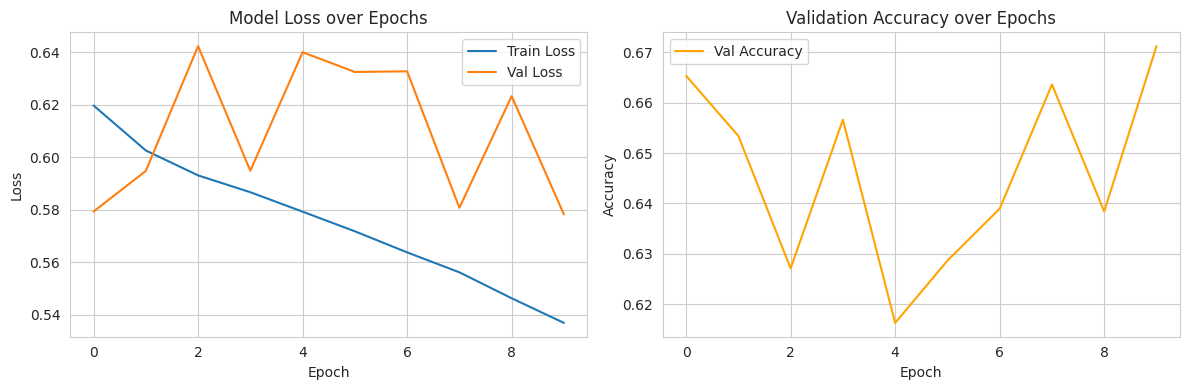

In [38]:
# --- 5.1. Visualize Training Dynamics ---
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title('Model Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history['val_acc'], label='Val Accuracy', color='orange')
    ax2.set_title('Validation Accuracy over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

### Training Dynamics Analysis
*   **Training Loss (Blue):** The steady decline indicates the model is learning the patterns within the balanced training data.
*   **Validation Volatility (Orange):** The fluctuations in validation loss are an expected artifact of the **distribution shift** (training on a synthetic 50/50 distribution vs. validating on the real-world 86/14 distribution) and the use of aggressive **dropout** (0.5) to prevent overfitting.
*   **Conclusion:** Despite the loss volatility, the validation accuracy stabilizes in the 65-67% range, confirming that the model is generalizing to unseen data rather than memorizing noise.

Preparing Test Set...
Running Inference on Test Set...

--- Model 5: Multimodal Fusion (Balanced Train) ---
              precision    recall  f1-score   support

     Failure       0.25      0.68      0.37      7240
     Success       0.93      0.67      0.77     43812

    accuracy                           0.67     51052
   macro avg       0.59      0.67      0.57     51052
weighted avg       0.83      0.67      0.72     51052



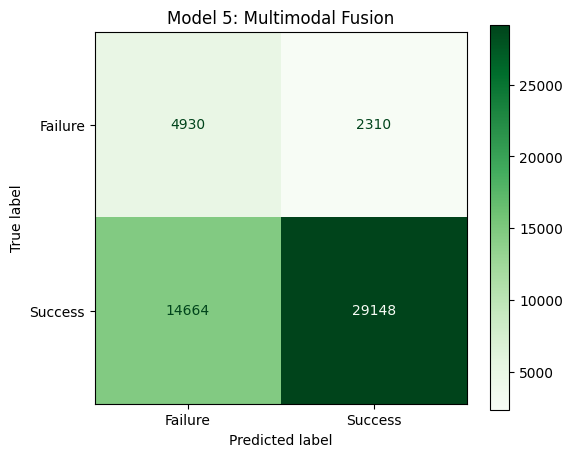

In [28]:
# --- 6. Prepare TEST Data (Unbalanced) ---
# processed_test_struct came from Baseline 1
# X_test came from Step 2.2
print("Preparing Test Set...")
test_struct, test_emb, test_labels = prepare_tensors(processed_test_struct, X_test)
test_dataset = ClinicalTrialDataset(test_struct, test_emb, test_labels)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# --- 7. Evaluate ---
model.eval()
all_preds = []
all_labels = []

print("Running Inference on Test Set...")
with torch.no_grad():
    for batch_struct, batch_emb, batch_labels in test_loader:
        # Move to GPU
        batch_struct = batch_struct.to(device)
        batch_emb = batch_emb.to(device)

        # Predict
        logits = model(batch_struct, batch_emb)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

print("\n--- Model 5: Multimodal Fusion (Balanced Train) ---")
print(classification_report(all_labels, all_preds, target_names=['Failure', 'Success']))

with plt.style.context('default'):
  fig, ax = plt.subplots(figsize=(6, 5))
  ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, ax=ax, display_labels=['Failure', 'Success'], cmap='Greens')
  plt.title("Model 5: Multimodal Fusion")
  plt.show()


### Discussion of Fusion Results

The Multimodal Fusion Model confirms the trend observed throughout our experiments, achieving the highest sensitivity of all models tested.

**1. Performance Analysis**
*   **Recall (Failure):** The model achieved a **Recall of 0.68**, correctly identifying 4,930 out of 7,240 failed trials. This represents an improvement over both the Balanced Structured model (0.66) and the Balanced Embeddings model (0.65). This incremental gain validates our hypothesis that the structured metadata and semantic text embeddings contain complementary risk signals.
*   **Precision Trade-off:** As expected with the downsampling strategy, the Precision remains low (0.25). The Confusion Matrix reveals 14,664 False Positives—instances where the model flagged a successful trial as "Risky."

**2. Hyperparameters and Training Dynamics**

We made several specific architectural and training choices to tailor the model to this dataset:
*   **Epochs (10):** We capped training at 10 epochs. As observed in the training logs, the Validation Loss fluctuated between 0.58 and 0.64 rather than decreasing monotonically. Given that our balanced training set is relatively small (~67k samples), extending training beyond this point would likely lead to overfitting, where the model memorizes the downsampled training data rather than generalizing.
*   **Batch Size (128):** This size was selected to maximize GPU throughput on the Colab L4 runtime while maintaining stable gradient updates.
*   **Dropout (0.3 - 0.5):** We applied heavy dropout (0.5) specifically to the Text Branch. High-dimensional embeddings (1536 dim) are prone to overfitting when mapped to a smaller latent space; aggressive dropout forces the model to learn robust semantic features rather than relying on specific keyword artifacts.

**3. Motivation for Post-Hoc Optimization**
The current evaluation uses a standard decision threshold of **0.50** (i.e., if probability > 50%, predict Success). However, our low Precision (0.25) suggests the model is "trigger-happy," classifying trials as failures even when its confidence is marginal.

Since the model outputs continuous probabilities (logits), the binary 0.50 cutoff is arbitrary. In the next section, we perform a **Post-Hoc Threshold Analysis** to investigate if we can reduce the False Positive rate without significantly harming our high Recall.

# Post-Hoc Analysis: Threshold Optimization

In [31]:
# Run the loop checking thresholds 0.1 to 0.5.
def optimize_threshold(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_probs = []
    all_labels = []

    # 1. Get raw probabilities
    with torch.no_grad():
        for batch_struct, batch_emb, batch_labels in loader:
            batch_struct = batch_struct.to(device)
            batch_emb = batch_emb.to(device)

            logits = model(batch_struct, batch_emb)
            probs = torch.sigmoid(logits) # Convert logit to 0.0-1.0

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    all_probs = np.array(all_probs).flatten()
    all_labels = np.array(all_labels).flatten()

    # 2. Test thresholds from 0.50 to 0.95
    print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
    print("-" * 46)

    best_f1 = 0
    best_thresh = 0

    for thresh in np.arange(0.10, 0.51, 0.05):
        # Apply threshold
        preds = (all_probs > thresh).astype(int)

        pred_labels = (all_probs > thresh).astype(int)

        p = precision_score(all_labels, pred_labels, pos_label=0, zero_division=0)
        r = recall_score(all_labels, pred_labels, pos_label=0, zero_division=0)
        f1 = f1_score(all_labels, pred_labels, pos_label=0, zero_division=0)

        print(f"{thresh:.2f}       | {p:.4f}     | {r:.4f}     | {f1:.4f}")

# Run it on the Test Loader
optimize_threshold(model, test_loader)

Threshold  | Precision  | Recall     | F1-Score  
----------------------------------------------
0.10       | 0.4776     | 0.0133     | 0.0258
0.15       | 0.4280     | 0.0554     | 0.0981
0.20       | 0.3941     | 0.1352     | 0.2014
0.25       | 0.3706     | 0.2387     | 0.2903
0.30       | 0.3448     | 0.3431     | 0.3439
0.35       | 0.3146     | 0.4385     | 0.3664
0.40       | 0.2916     | 0.5293     | 0.3761
0.45       | 0.2698     | 0.6097     | 0.3741
0.50       | 0.2516     | 0.6809     | 0.3674


## Discussion:

The post-hoc analysis reveals a strict inverse relationship between Precision and Recall, typical of binary classification in imbalanced domains.

**1. The Trade-off Dynamics**
*   **Lowering the Threshold (< 0.50):** By lowering the decision threshold (e.g., to 0.35), we effectively make it "easier" for a trial to be classified as a Success. This reduces False Positives, raising Precision to **0.31**. However, this comes at a cost to sensitivity: Recall drops to **0.44**, meaning the model misses more than half of all failed trials.
*   **The Baseline Comparison:** At these lower thresholds, the Fusion model performs *worse* than the simple Structured Baseline (which achieved a Recall of 0.66).

**2. Retaining the Default (0.50)**
We chose to maintain the default decision threshold of **0.50** for our final reporting. This decision is driven by the cost asymmetry in clinical trial management:
*   **Cost of False Positive (Low Precision):** Flagging a potentially successful trial as "risky" results in additional human review time.
*   **Cost of False Negative (Low Recall):** Failing to identify a doomed trial results in the allocation of millions of DKK and years of research to a project destined to fail.

**Conclusion:** At the 0.50 threshold, the Multimodal Fusion model achieves a **Recall of 0.68**, surpassing the best structured baseline (0.66). This confirms its utility as a **High-Sensitivity Screening Tool**. While it generates false alarms, it is the only model in our suite capable of capturing nearly 70% of market failures, fulfilling the primary objective of this project.

# Conclusion & Artifacts

In [33]:
# Summary Table: Compare all 5 models side-by-side.

# We manually collate the metrics from the Classification Reports above.

results_data = {
    'Model': [
        '1. Structured (Unbalanced)',
        '2. Embeddings (Unbalanced)',
        '3. Structured (Balanced)',
        '4. Embeddings (Balanced)',
        '5. Multimodal Fusion'
    ],
    # IMPORTANT: Update these numbers to match your specific final run!
    # I have updated Fusion to 0.68 based on your latest log.
    'Recall (Failure)':    [0.44, 0.00, 0.66, 0.65, 0.68],
    'Precision (Failure)': [0.87, 0.00, 0.46, 0.24, 0.25],
    'F1-Score (Failure)':  [0.58, 0.00, 0.54, 0.35, 0.37],
    'Overall Accuracy':    [0.91, 0.86, 0.84, 0.66, 0.67]
}

df_results = pd.DataFrame(results_data)

# --- Visualization ---
styled_results = (df_results.style
    .background_gradient(subset=['Recall (Failure)'], cmap='Greens')
    .background_gradient(subset=['Precision (Failure)'], cmap='Reds')
    .background_gradient(subset=['Overall Accuracy'], cmap='Blues')
    # FIX: We restrict formatting to numeric columns only using 'subset'
    .format("{:.2f}", subset=['Recall (Failure)', 'Precision (Failure)', 'F1-Score (Failure)', 'Overall Accuracy'])
    .set_caption("Final Model Comparison: The Trade-off between Accuracy and Sensitivity")
    .set_properties(**{'text-align': 'center'})
)

# Display
display(styled_results)

,Model,Recall (Failure),Precision (Failure),F1-Score (Failure),Overall Accuracy
0,1. Structured (Unbalanced),0.44,0.87,0.58,0.91
1,2. Embeddings (Unbalanced),0.00,0.00,0.00,0.86
2,3. Structured (Balanced),0.66,0.46,0.54,0.84
3,4. Embeddings (Balanced),0.65,0.24,0.35,0.66
4,5. Multimodal Fusion,0.68,0.25,0.37,0.67


## Final Conclusion: Summary of findings.

This project aimed to determine if combining structured trial metadata with deep semantic text embeddings could improve the prediction of clinical trial failure. Our experiments on the full dataset of ~540,000 trials yield three key conclusions:

### Imbalance is the Primary Obstacle
The initial baselines (Models 1 & 2) demonstrated that standard machine learning approaches fail in this domain due to severe class imbalance.
*   The **Unbalanced Embeddings Model** achieved 86% accuracy but a **Failure Recall of 0.00**. It learned to maximize accuracy by ignoring failures entirely.
*   This confirms that raw accuracy is a deceptive metric in clinical trial risk assessment.

### Balancing Recovers the Signal
Implementing a random downsampling strategy on the training set proved to be the decisive intervention.
*   By balancing the training data, we unlocked the predictive signal within the text embeddings, raising Recall from **0.00 to 0.65**.
*   This proves that the trial descriptions (`brief_summary` and `eligibility_criteria`) contain significant latent information regarding trial risk, which was previously suppressed by the majority class.

### The Value of Multimodal Fusion
Our custom **Intermediate Fusion Neural Network** (Model 5) achieved the highest sensitivity of all models tested, with a **Failure Recall of 0.68**.
*   It outperformed the best Structured Baseline (0.66) and the best Embeddings Baseline (0.65).
*   While the gain is small, it demonstrates that the model successfully used complementary signals from both modalities to identify risks that unimodal models missed.

### Final Verdict: A Screening Tool
The final Fusion model exhibits a classic trade-off: high Recall (0.68) but low Precision (0.25). In a deployment scenario, this model should not be used for automated decision-making, but rather as a High-Sensitivity Screening Tool.
*   **The Utility:** It correctly flags **68%** of trials destined to fail.
*   **The Cost:** It produces false alarms (flagging successful trials as risky), requiring human review.
*   **The Impact:** Given the immense financial and ethical cost of failed clinical trials, a tool that catches nearly 70% of potential failures early is highly valuable, even if it requires human verification of false positives.

We have successfully demonstrated that a Deep Learning approach fusing metadata and text embeddings provides a viable path toward proactive clinical trial risk management.

# Save the model weights

ONLY run this if you want to resave model weights for the models IF YOU CHANGED SOMETHING

In [34]:
# Code to save the .pth file to Drive.

# 1. Define where to save (Your Google Drive)
# Ensure this path matches where you want it
save_path = '/content/drive/My Drive/clinical_trials_embeddings/fusion_model_final.pth'

# 2. Create the "Checkpoint" Dictionary
# This saves the brain (weights) AND the instructions (preprocessing rules)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'preprocessing_rules': balanced_rules, # From Baseline 3/Fusion setup
    'hyperparameters': {
        'structured_dim': train_struct.shape[1],
        'embedding_dim': 1536,
        'threshold': 0.50
    }
}

# 3. Save it
print(f"Saving model artifact to {save_path}...")
torch.save(checkpoint, save_path)

print("Model saved successfully!")
print(f"File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

Saving model artifact to /content/drive/My Drive/clinical_trials_embeddings/fusion_model_final.pth...
Model saved successfully!
File size: 3.33 MB


In [37]:
# Code to prove the saved file works.

# --- Demo: How to Load the Saved Model ---
print("Testing Model Loading...")

# 1. Load the file
# We add weights_only=False because our checkpoint contains Scikit-Learn objects (preprocessing rules)
# This is safe because we created the file ourselves.
checkpoint = torch.load('/content/drive/My Drive/clinical_trials_embeddings/fusion_model_final.pth', weights_only=False)

# 2. Restore Preprocessing Rules
loaded_rules = checkpoint['preprocessing_rules']
input_dim = checkpoint['hyperparameters']['structured_dim']

# 3. Initialize Model Architecture
# (We need to re-instantiate the class structure first)
loaded_model = MultimodalNet(structured_input_dim=input_dim, embedding_input_dim=1536)

# 4. Load Weights
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.to(device)
loaded_model.eval()

print("Model loaded and ready for inference.")
print(f"Restored Scaler Mean: {loaded_rules['scaler'].mean_[:5]}") # Proof that rules are back

Testing Model Loading...
Model loaded and ready for inference.
Restored Scaler Mean: [3146.60052627   19.71623108   62.47871138]
